![thumbnail](https://raw.githubusercontent.com/lko9911/Kaggle/master/thumbnail/thumbnail.png)


<div style="
    padding: 20px;
    color: white;
    margin: 0;
    font-size: 300%;
    font-weight: 800;
    text-align: center;
    display: fill;
    border-radius: 60px;
    background-color: #D8CEF6;
    box-shadow: 0 4px 8px rgba(0, 0, 0, 0.2);
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
    Predict Net Sales<br>
    (ML)
</div>

# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Import Libraries & Read Dataset</div>

In [1]:
# For EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# For Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import os
import glob

# For Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam

2026-02-14 01:33:41.997605: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771032822.237507      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771032822.307310      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771032822.883312      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771032822.883375      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771032822.883378      17 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_csv('/kaggle/input/dayaset-2020/SalesMind_Stores_Master_2026.csv')
df.head()

,store_id,city,region,store_type,population_density
0,1,London,Europe,Online,4657
1,7,New York,North America,Hybrid,4257
2,11,Toronto,North America,Online,6514
3,18,New York,Europe,Online,5803
4,8,New York,Europe,Offline,8428


# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Data preprocessing</div>

In [3]:
base_path = "/kaggle/input/dayaset-2020/"

files = [
    "SalesMind_Stores_Master_2026.csv",
    "SalesMind_Products_Master_2026.csv",
    "SalesMind_Sales_Transactions_2026.csv",
    "SalesMind_External_Factors_2026.csv",
    "SalesMind_Calendar_Dimension_2026.csv",
    "SalesMind_Marketing_Campaigns_2026.csv",
    "SalesMind_Customer_Segments_2026.csv",
    "SalesMind_Inventory_Supply_2026.csv"
]

dfs = {}

for file in files:
    name = file.replace(".csv", "")
    dfs[name] = pd.read_csv(os.path.join(base_path, file))


print(dfs.keys())

dict_keys(['SalesMind_Stores_Master_2026', 'SalesMind_Products_Master_2026', 'SalesMind_Sales_Transactions_2026', 'SalesMind_External_Factors_2026', 'SalesMind_Calendar_Dimension_2026', 'SalesMind_Marketing_Campaigns_2026', 'SalesMind_Customer_Segments_2026', 'SalesMind_Inventory_Supply_2026'])


In [4]:
dfs["SalesMind_Sales_Transactions_2026"].head()

,transaction_id,date,product_id,store_id,customer_segment,units_sold,total_sales_revenue,total_discount_given,net_sales,gross_profit,return_rate
0,1,2023-01-01,1,1,Budget,90,19668.60,471.98,19196.62,3752.62,0.02
1,2,2023-01-02,2,7,Enterprise,103,5186.05,432.86,4753.19,616.71,0.04
2,3,2023-01-03,3,11,Budget,105,42349.65,4457.01,37892.64,14180.49,0.04
3,4,2023-01-04,4,18,Enterprise,31,4912.26,72.77,4839.49,1376.48,0.06
4,5,2023-01-05,5,8,Enterprise,112,54466.72,3034.65,51432.07,11533.19,0.08


In [5]:
path = "/kaggle/input/dayaset-2020/*.csv"
file_list = glob.glob(path)

for file in file_list:
    name = os.path.basename(file)
    df = pd.read_csv(file)
    
    print(f"\n===== {name} =====")
    display(df.head())


===== SalesMind_Stores_Master_2026.csv =====


,store_id,city,region,store_type,population_density
0,1,London,Europe,Online,4657
1,7,New York,North America,Hybrid,4257
2,11,Toronto,North America,Online,6514
3,18,New York,Europe,Online,5803
4,8,New York,Europe,Offline,8428



===== SalesMind_Products_Master_2026.csv =====


,product_id,product_category,brand,product_price,cost_price,profit_margin
0,1,Electric Accessories,NextTech,218.54,171.60,46.94
1,2,Smart Wearables,NextTech,50.35,40.16,10.19
2,3,Electric Accessories,FutureX,403.33,225.83,177.50
3,4,Electric Accessories,FutureX,158.46,111.71,46.75
4,5,AI Gadgets,NextTech,486.31,356.24,130.07



===== SalesMind_Sales_Transactions_2026.csv =====


...

,campaign_id,ad_channel,campaign_type,marketing_spend,conversion_rate,impressions
0,1,Google,Brand Awareness,14907.88,0.17,49540
1,2,Email,Seasonal,12732.15,0.15,30439
2,3,Google,Flash Sale,10770.45,0.13,7338
3,4,TikTok,Brand Awareness,12589.94,0.15,13601
4,5,TikTok,Seasonal,18850.48,0.21,25260



===== SalesMind_Customer_Segments_2026.csv =====


,customer_segment,repeat_customer_rate,loyalty_member_ratio,customer_satisfaction_score,churn_rate
0,Budget,0.48,0.30,3.29,0.15
1,Enterprise,0.46,0.27,4.22,0.07
2,Budget,0.47,0.11,4.88,0.13
3,Enterprise,0.75,0.26,4.33,0.10
4,Enterprise,0.54,0.41,4.92,0.18



===== SalesMind_Inventory_Supply_2026.csv =====


,inventory_id,product_id,store_id,inventory_level,supplier_lead_time,stockout_flag
0,1,1,1,329,7,1
1,2,2,7,351,13,0
2,3,3,11,233,16,1
3,4,4,18,410,7,0
4,5,5,8,231,11,1


In [6]:
for file in file_list:
    name = os.path.basename(file)
    df = pd.read_csv(file)
    
    print(f"\n===== {name} =====")
    display(df.info())


===== SalesMind_Stores_Master_2026.csv =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3499 entries, 0 to 3498
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   store_id            3499 non-null   int64 
 1   city                3499 non-null   object
 2   region              3499 non-null   object
 3   store_type          3499 non-null   object
 4   population_density  3499 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 136.8+ KB


None


===== SalesMind_Products_Master_2026.csv =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        3500 non-null   int64  
 1   product_category  3500 non-null   object 
 2   brand             3500 non-null   object 
 3   product_price     3500 non-null   float64
 4   cost_price        3500 non-null   float64
 5   profit_margin     3500 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 164.2+ KB


None


===== SalesMind_Sales_Transactions_2026.csv =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_id        3500 non-null   int64  
 1   date                  3500 non-null   object 
 2   product_id            3500 non-null   int64  
 3   store_id              3500 non-null   int64  
 4   customer_segment      3500 non-null   object 
 5   units_sold            3500 non-null   int64  
 6   total_sales_revenue   3500 non-null   float64
 7   total_discount_given  3500 non-null   float64
 8   net_sales             3500 non-null   float64
 9   gross_profit          3500 non-null   float64
 10  return_rate           3500 non-null   float64
dtypes: float64(5), int64(4), object(2)
memory usage: 300.9+ KB


...

None


===== SalesMind_Customer_Segments_2026.csv =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_segment             3500 non-null   object 
 1   repeat_customer_rate         3500 non-null   float64
 2   loyalty_member_ratio         3500 non-null   float64
 3   customer_satisfaction_score  3500 non-null   float64
 4   churn_rate                   3500 non-null   float64
dtypes: float64(4), object(1)
memory usage: 136.8+ KB


None


===== SalesMind_Inventory_Supply_2026.csv =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   inventory_id        3500 non-null   int64
 1   product_id          3500 non-null   int64
 2   store_id            3500 non-null   int64
 3   inventory_level     3500 non-null   int64
 4   supplier_lead_time  3500 non-null   int64
 5   stockout_flag       3500 non-null   int64
dtypes: int64(6)
memory usage: 164.2 KB


None

In [7]:
df_sales = dfs["SalesMind_Sales_Transactions_2026"].copy()
df_products = dfs["SalesMind_Products_Master_2026"].copy()
df_stores = dfs["SalesMind_Stores_Master_2026"].copy()
df_calendar = dfs["SalesMind_Calendar_Dimension_2026"].copy()
df_external = dfs["SalesMind_External_Factors_2026"].copy()
df_inventory = dfs["SalesMind_Inventory_Supply_2026"].copy()
df_segments = dfs["SalesMind_Customer_Segments_2026"].copy()


print("stores shape:", df_stores.shape)
print("unique store_id:", df_stores["store_id"].nunique())


stores shape: (3499, 5)
unique store_id: 20


In [8]:
df_products = df_products.drop_duplicates("product_id")
df_stores = df_stores.drop_duplicates("store_id")
df_calendar = df_calendar.drop_duplicates("date")
df_external = df_external.drop_duplicates("date")
df_segments = df_segments.drop_duplicates("customer_segment")
df_inventory = df_inventory.drop_duplicates(["product_id","store_id"])

df = df_sales.merge(df_products, on="product_id", how="left")
df = df.merge(df_stores, on="store_id", how="left")
df = df.merge(df_calendar, on="date", how="left")
df = df.merge(df_external, on="date", how="left")
df = df.merge(df_inventory, on=["product_id","store_id"], how="left")
df = df.merge(df_segments, on="customer_segment", how="left")

print(df.shape) 

(3500, 38)


In [9]:
df["date"] = pd.to_datetime(df["date"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   transaction_id               3500 non-null   int64         
 1   date                         3500 non-null   datetime64[ns]
 2   product_id                   3500 non-null   int64         
 3   store_id                     3500 non-null   int64         
 4   customer_segment             3500 non-null   object        
 5   units_sold                   3500 non-null   int64         
 6   total_sales_revenue          3500 non-null   float64       
 7   total_discount_given         3500 non-null   float64       
 8   net_sales                    3500 non-null   float64       
 9   gross_profit                 3500 non-null   float64       
 10  return_rate                  3500 non-null   float64       
 11  product_category             3500 non-null 

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
transaction_id,3500.0,1750.5,1.0,875.75,1750.5,2625.25,3500.0,1010.507298
date,3500,2027-10-16 12:00:00,2023-01-01 00:00:00,2025-05-24 18:00:00,2027-10-16 12:00:00,2030-03-09 06:00:00,2032-07-31 00:00:00,NaN
product_id,3500.0,1750.5,1.0,875.75,1750.5,2625.25,3500.0,1010.507298
store_id,3500.0,10.698571,1.0,6.0,11.0,16.0,20.0,5.719883
units_sold,3500.0,64.022571,9.0,41.0,63.0,85.0,146.0,26.945327
total_sales_revenue,3500.0,17488.288551,885.7,8039.6925,14918.46,24456.575,66038.52,11765.161556
total_discount_given,3500.0,1405.716389,21.2,458.0575,1012.24,1948.5725,8635.76,1270.827937
net_sales,3500.0,16082.572163,755.7,7383.0825,13735.22,22423.8225,61741.81,10860.083108
gross_profit,3500.0,4669.053514,78.76,1869.87,3600.625,6281.0075,27756.95,3764.873682
return_rate,3500.0,0.05476,0.01,0.03,0.05,0.08,0.1,0.026321


In [12]:
print("Missing Value (%)")
missing_values = df.isna().mean() * 100
print(missing_values)

print("\nDuplicate Rows (%):")
duplicate_count = df.duplicated().mean()
print(duplicate_count)

Missing Value (%)
transaction_id                 0.0
date                           0.0
product_id                     0.0
store_id                       0.0
customer_segment               0.0
units_sold                     0.0
total_sales_revenue            0.0
total_discount_given           0.0
net_sales                      0.0
gross_profit                   0.0
return_rate                    0.0
product_category               0.0
brand                          0.0
product_price                  0.0
cost_price                     0.0
profit_margin                  0.0
city                           0.0
region                         0.0
store_type                     0.0
population_density             0.0
month                          0.0
quarter                        0.0
year                           0.0
week_of_year                   0.0
is_weekend                     0.0
season                         0.0
external_id                    0.0
inflation_rate                 0.0
co

In [13]:
def outlier_check(row, colname):  
    Q1 = row[colname].quantile(0.25)
    Q3 = row[colname].quantile(0.75)
    IQR = Q3 - Q1
    lower_b = Q1 - 1.5 * IQR
    upper_b = Q3 + 1.5 * IQR
    outlier = row.loc[(row[colname] < lower_b) | (row[colname] > upper_b)]
    return outlier
    
outliers = pd.DataFrame() 

for col in df.select_dtypes(include=['number']).columns: 
    outliers_in_col = outlier_check(df, col) 
    outliers = pd.concat([outliers, outliers_in_col])

outliers.reset_index(drop=True, inplace=True)

total_rows = len(df)
outlier_count = len(outliers)
outlier_ratio = (outlier_count / total_rows) * 100

if outliers.empty:
    print("No outliers")
else:
    print(f"Number of Outliers: {outlier_count}")
    print(f"Outlier Ratio: {outlier_ratio:.2f}%")

Number of Outliers: 418
Outlier Ratio: 11.94%


In [14]:
obj_cols = df.select_dtypes(include='object')

for col in obj_cols.columns:
    print(f"{col} unique values:")
    print(obj_cols[col].unique())
    print("-" * 30)

customer_segment unique values:
['Budget' 'Enterprise' 'Premium']
------------------------------
product_category unique values:
['Electric Accessories' 'Smart Wearables' 'AI Gadgets']
------------------------------
brand unique values:
['NextTech' 'FutureX' 'VoltPro']
------------------------------
city unique values:
['London' 'New York' 'Toronto']
------------------------------
region unique values:
['Europe' 'North America']
------------------------------
store_type unique values:
['Online' 'Hybrid' 'Offline']
------------------------------
season unique values:
['Winter' 'Spring' 'Summer' 'Autumn']
------------------------------
weather_condition unique values:
['Sunny' 'Rainy' 'Snowy' 'Cloudy']
------------------------------


In [15]:
print(df.columns.tolist())

['transaction_id', 'date', 'product_id', 'store_id', 'customer_segment', 'units_sold', 'total_sales_revenue', 'total_discount_given', 'net_sales', 'gross_profit', 'return_rate', 'product_category', 'brand', 'product_price', 'cost_price', 'profit_margin', 'city', 'region', 'store_type', 'population_density', 'month', 'quarter', 'year', 'week_of_year', 'is_weekend', 'season', 'external_id', 'inflation_rate', 'competitor_price', 'weather_condition', 'inventory_id', 'inventory_level', 'supplier_lead_time', 'stockout_flag', 'repeat_customer_rate', 'loyalty_member_ratio', 'customer_satisfaction_score', 'churn_rate']


In [16]:
df = pd.get_dummies(df, columns=[
    'customer_segment', 'product_category', 'brand', 
    'city', 'store_type', 'season', 'weather_condition'
])

df['region'] = df['region'].map({'Europe':0, 'North America':1})

df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek  
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['year'] = df['date'].dt.year
df['is_weekend'] = (df['day_of_week'] >=5).astype(int)

df_model = df.drop(columns=['date', 'transaction_id', 'inventory_id', 'external_id'])

num_cols = df_model.select_dtypes(include=['int64','float64']).columns.tolist()
scaler = RobustScaler()
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">EDA : Correlation Analysis</div>

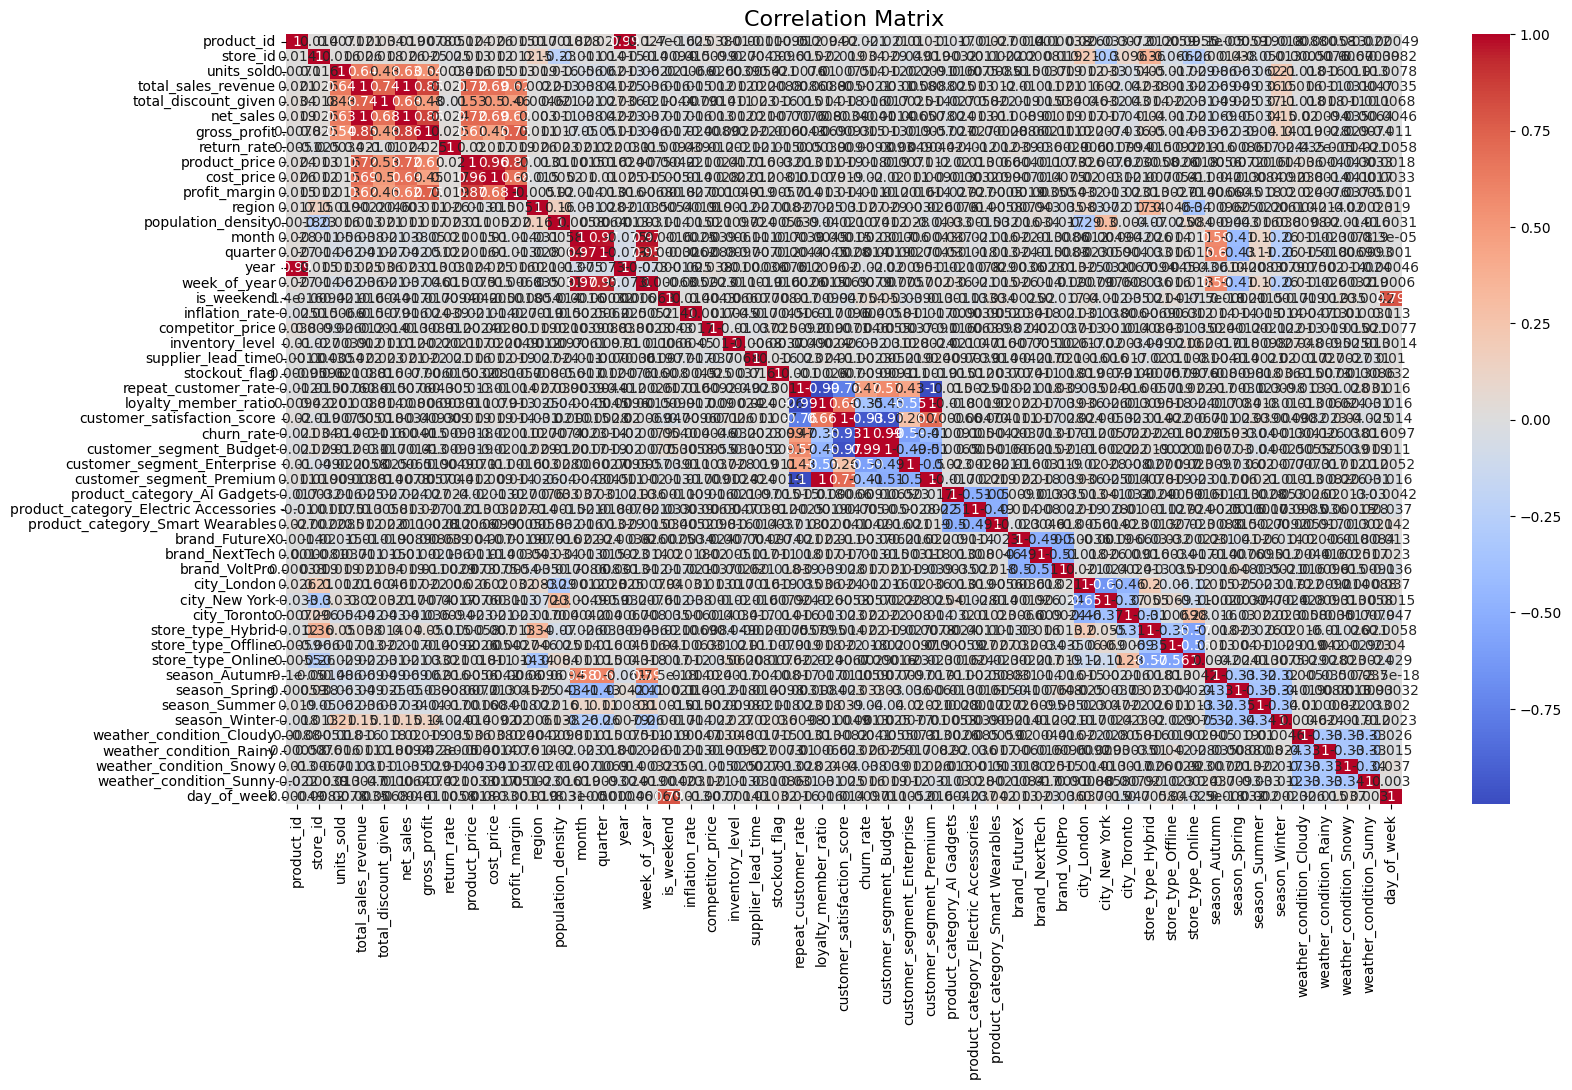

In [17]:
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df_model[column] = label_encoders[column].fit_transform(df_model[column])

correlation_matrix = df_model.corr(method='pearson')

plt.figure(figsize=(18, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Comparison of Machine Learning Model Performance</div>

In [18]:
X = df_model.drop(columns=[
    'net_sales', 
    'total_discount_given', 
    'total_sales_revenue',
    'gross_profit' 
])
y = df_model['net_sales']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.01, random_state=42),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "KNN": KNeighborsRegressor(n_neighbors=3),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    )
}

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return mae, mse, rmse, r2

In [19]:
results = {}

for name, model in models.items():
    mae, mse, rmse, r2 = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )
    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

results_df = pd.DataFrame(results).T  
results_df = results_df.round(4)     

results_df = results_df.reset_index().rename(columns={"index": "Model"})

results_df = results_df.round(4)     
results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.1665,0.0482,0.2196,0.9024
1,Ridge,0.1664,0.0481,0.2192,0.9027
2,Lasso,0.1612,0.0470,0.2167,0.9049
3,SVR,0.0766,0.0097,0.0986,0.9803
4,KNN,0.3421,0.2034,0.4510,0.5883
5,Decision Tree,0.0734,0.0123,0.1107,0.9752
6,Random Forest,0.0447,0.0042,0.0645,0.9916
7,XGBoost,0.0440,0.0041,0.0643,0.9916


# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Results</div>

Model,MAE,MSE,RMSE,R2
XGBoost,0.044000,0.004100,0.064300,0.991600
Random Forest,0.044700,0.004200,0.064500,0.991600
SVR,0.076600,0.009700,0.098600,0.980300
Decision Tree,0.073400,0.012300,0.110700,0.975200
Lasso,0.161200,0.047000,0.216700,0.904900
Ridge,0.166400,0.048100,0.219200,0.902700
Linear Regression,0.166500,0.048200,0.219600,0.902400
KNN,0.342100,0.203400,0.451000,0.588300



Best Model (Overall):


Model,MAE,MSE,RMSE,R2
XGBoost,0.044000,0.004100,0.064300,0.991600


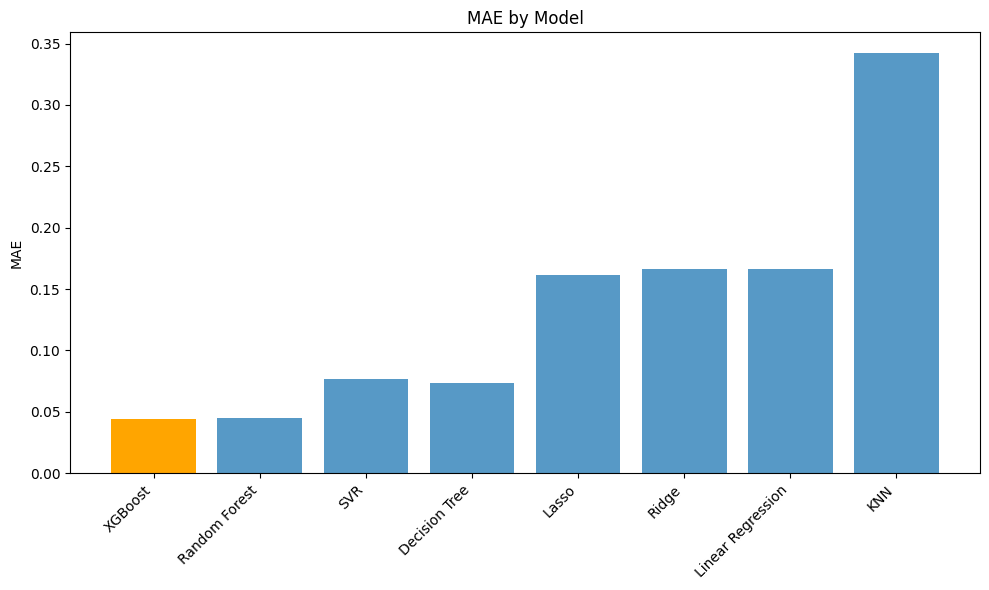

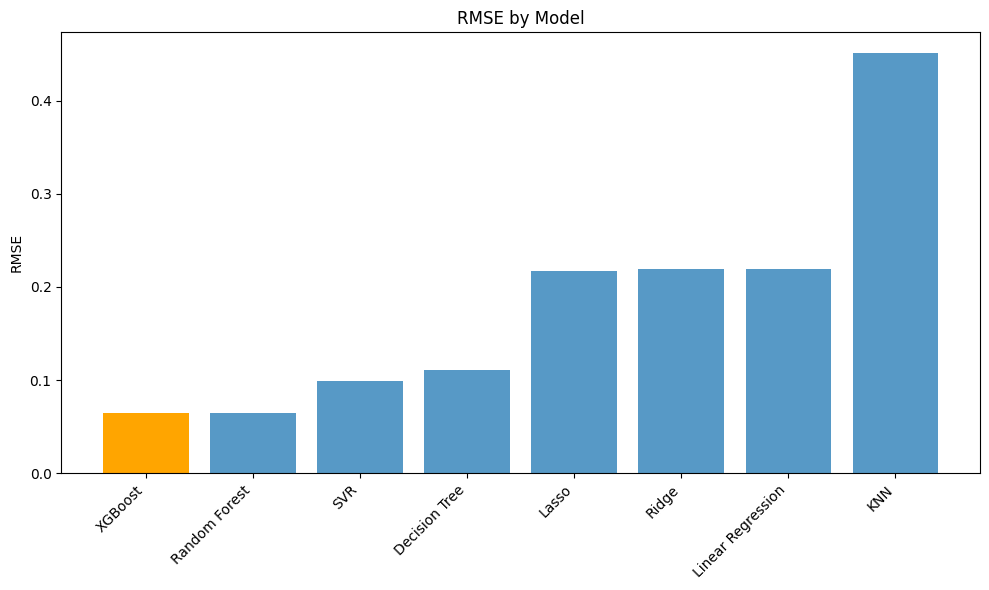

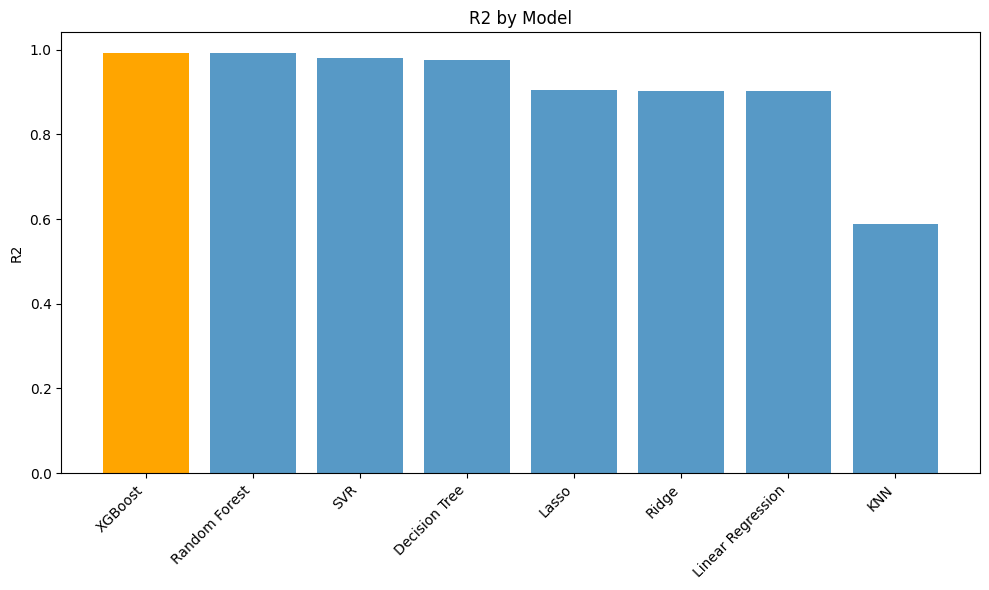


Optimal Model based on RMSE: XGBoost (RMSE = 0.0643, R2 = 0.9916)


In [20]:
standard_cols = ["Model", "MAE", "MSE", "RMSE", "R2"]
results_df = results_df[standard_cols]

results_df = results_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

best_model = results_df.iloc[0]

display(results_df.style.hide(axis="index"))

print("\nBest Model (Overall):")
display(pd.DataFrame([best_model]).style.hide(axis="index"))

metrics = ["MAE", "RMSE", "R2"]

for metric in metrics:
    plt.figure(figsize=(10, 6))
    plt.bar(results_df["Model"], results_df[metric], alpha=0.75)
    plt.bar(best_model["Model"], best_model[metric], color='orange')
    plt.ylabel(metric)
    plt.title(f"{metric} by Model")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

print(f"\nOptimal Model based on RMSE: {best_model['Model']} "
      f"(RMSE = {best_model['RMSE']:.4f}, R2 = {best_model['R2']:.4f})")

<div style="display: inline-block; padding: 10px 15px; border-radius: 20px; background: linear-gradient(135deg, #ff7f50, #ff1493); box-shadow: 5px 5px 15px rgba(0, 0, 0, 0.3); font-size: 30px; font-family: 'Helvetica Neue', Arial, sans-serif; color: #ffffff; text-align: center; border: 2px solid #ffffff;">Thanks !</div><br><br>

<h3> Feel free to ask any questions and use the code freely! </h3><br>
<h3> If this helped you, improved performance, or if you want fine-tuning tips, please vote! It really helps a lot!! </h3><br>
<div style="text-align: center;">
    <a href="https://www.kaggle.com/lko9911" target="_blank" style="display: inline-block; background-color: #3a86ff; color: #fff; text-decoration: none; padding: 5px 10px; border-radius: 10px; margin: 15px; font-size: 25px;">Kaggle</a>
    <a href="https://github.com/lko9911" target="_blank" style="display: inline-block; background-color: #ff8c00; color: #ffffff; text-decoration: none; padding: 5px 20px; border-radius: 15px; margin: 15px; border: 2px solid #ff4500; font-size: 25px; font-family: 'Arial', sans-serif; font-weight: bold; transition: all 0.3s ease;">GitHub</a></div>